#  Gym Member Churn Risk Prediction
## Predicting Monthly Churn Probability using Lasso & Ridge Regression

### Problem Statement:

Fitness centers and gym chains face a persistent revenue challengew.

#### Project Workflow
1) Import Libraries
2) Load Dataset
3) Data Understanding
4) Data Cleaning & Preprocessing
5) Exploratory Data Analysis (EDA)
6) Feature Engineering (if required)
7) Correlation Analysis
8) Model Building using Lasso & Regression Regression
9) Model Evaluation
10) Conclusions and Recommendations

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso,Ridge,LassoCV,RidgeCV,LogisticRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor


In [2]:
#Load the dataset
try:
    data = pd.read_csv("data/gym_churn_dataset.csv")
    print("Data successfully Loaded")

except FileNotFoundError as e:
    print(f'File error is {e}')

Data successfully Loaded


In [3]:
data.head()

,Member_ID,Name,Age,Gender,Membership_Type,Membership_Duration_Months,Attendance_Frequency_Per_Week,Last_Checkin_Days_Ago,Monthly_Fee,Payment_Delay_Count,...,Workout_Sessions_Completed,Personal_Trainer,Group_Class_Participation,BMI,Distance_From_Gym_km,App_Usage_Hours,Renewal_Count,Goal_Type,UPI_Payment_Usage,Churn_Status
0,GYM100000,Rohan Dayal,56.0,Male,Half-Yearly,29,3.0,17,5856.0,7,...,131,Yes,22,16.4,6.5,7.5,4,Bodybuilding,Yes,0
1,GYM100001,Himmat Baral,46.0,??,Quarterly,32,3.0,50,1046.0,2,...,152,Yes,10,30.4,21.2,27.0,1,Fitness,No,1
2,GYM100002,Azad Manne,32.0,Female,Quarterly,16,5.0,45,2903.0,4,...,345,No,6,15.1,22.9,12.4,7,Weight Loss,No,1
3,GYM100003,Jayesh Jayaraman,60.0,Other,Annual,26,6.0,74,2918.0,8,...,333,No,5,25.1,19.2,15.4,3,Weight Loss,Yes,1
4,GYM100004,Azad Date,25.0,Female,Half-Yearly,6,6.0,58,4897.0,8,...,445,Yes,21,24.7,14.4,36.0,6,Bodybuilding,No,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20840 entries, 0 to 20839
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Member_ID                      20840 non-null  object 
 1   Name                           20840 non-null  object 
 2   Age                            19766 non-null  float64
 3   Gender                         20840 non-null  object 
 4   Membership_Type                20840 non-null  object 
 5   Membership_Duration_Months     20840 non-null  int64  
 6   Attendance_Frequency_Per_Week  19774 non-null  float64
 7   Last_Checkin_Days_Ago          20840 non-null  int64  
 8   Monthly_Fee                    19785 non-null  float64
 9   Payment_Delay_Count            20840 non-null  int64  
 10  Customer_Satisfaction_Score    19741 non-null  float64
 11  Workout_Sessions_Completed     20840 non-null  int64  
 12  Personal_Trainer               20840 non-null 

In [5]:
data.describe(include='all')

,Member_ID,Name,Age,Gender,Membership_Type,Membership_Duration_Months,Attendance_Frequency_Per_Week,Last_Checkin_Days_Ago,Monthly_Fee,Payment_Delay_Count,...,Workout_Sessions_Completed,Personal_Trainer,Group_Class_Participation,BMI,Distance_From_Gym_km,App_Usage_Hours,Renewal_Count,Goal_Type,UPI_Payment_Usage,Churn_Status
count,20840,20840,19766.000000,20840,20840,20840.000000,19774.000000,20840.000000,19785.000000,20840.000000,...,20840.000000,20840,20840.000000,20840.000000,20840.000000,20840.000000,20840.000000,20840,20840,20840.000000
unique,20000,17972,NaN,7,5,NaN,NaN,NaN,NaN,NaN,...,NaN,2,NaN,NaN,NaN,NaN,NaN,5,2,NaN
top,GYM117443,Tiya Dhar,NaN,Male,Premium,NaN,NaN,NaN,NaN,NaN,...,NaN,No,NaN,NaN,NaN,NaN,NaN,Athletic Training,Yes,NaN
freq,2,5,NaN,11205,4196,NaN,NaN,NaN,NaN,NaN,...,NaN,13561,NaN,NaN,NaN,NaN,NaN,4251,16621,NaN
mean,NaN,NaN,41.791258,NaN,NaN,30.064203,3.913624,44.466027,5678.797271,4.504990,...,251.000384,NaN,14.499904,23.991756,12.756713,20.001641,3.508973,NaN,NaN,0.450864
std,NaN,NaN,19.645748,NaN,NaN,16.929637,5.771192,26.017561,12517.678670,2.875452,...,142.897609,NaN,8.690486,4.002944,7.090348,11.555894,2.285580,NaN,NaN,0.497592
min,NaN,NaN,-5.000000,NaN,NaN,1.000000,0.000000,0.000000,500.000000,0.000000,...,1.000000,NaN,0.000000,7.900000,0.500000,0.000000,0.000000,NaN,NaN,0.000000
25%,NaN,NaN,29.000000,NaN,NaN,16.000000,1.000000,22.000000,1943.000000,2.000000,...,128.000000,NaN,7.000000,21.300000,6.500000,10.100000,2.000000,NaN,NaN,0.000000
50%,NaN,NaN,41.000000,NaN,NaN,30.000000,3.000000,44.000000,3391.000000,4.000000,...,251.000000,NaN,15.000000,23.900000,12.800000,20.100000,4.000000,NaN,NaN,0.000000
75%,NaN,NaN,53.000000,NaN,NaN,45.000000,5.000000,67.000000,4812.000000,7.000000,...,374.000000,NaN,22.000000,26.700000,18.900000,30.000000,6.000000,NaN,NaN,1.000000


In [6]:
data.isnull().sum()

Member_ID                           0
Name                                0
Age                              1074
Gender                              0
Membership_Type                     0
Membership_Duration_Months          0
Attendance_Frequency_Per_Week    1066
Last_Checkin_Days_Ago               0
Monthly_Fee                      1055
Payment_Delay_Count                 0
Customer_Satisfaction_Score      1099
Workout_Sessions_Completed          0
Personal_Trainer                    0
Group_Class_Participation           0
BMI                                 0
Distance_From_Gym_km                0
App_Usage_Hours                     0
Renewal_Count                       0
Goal_Type                           0
UPI_Payment_Usage                   0
Churn_Status                        0
dtype: int64

In [7]:
missing_val = data.isna().sum().sort_values(ascending=False)
missing_df = pd.DataFrame({"Null":missing_val,"Percentage":(missing_val/len(data))*100})
missing_df

,Null,Percentage
Customer_Satisfaction_Score,1099,5.273512
Age,1074,5.153551
Attendance_Frequency_Per_Week,1066,5.115163
Monthly_Fee,1055,5.062380
Personal_Trainer,0,0.000000
UPI_Payment_Usage,0,0.000000
Goal_Type,0,0.000000
Renewal_Count,0,0.000000
App_Usage_Hours,0,0.000000
Distance_From_Gym_km,0,0.000000


In [8]:
data = data.dropna(subset=['Customer_Satisfaction_Score','Age','Attendance_Frequency_Per_Week','Monthly_Fee'])
data.isnull().sum()

Member_ID                        0
Name                             0
Age                              0
Gender                           0
Membership_Type                  0
Membership_Duration_Months       0
Attendance_Frequency_Per_Week    0
Last_Checkin_Days_Ago            0
Monthly_Fee                      0
Payment_Delay_Count              0
Customer_Satisfaction_Score      0
Workout_Sessions_Completed       0
Personal_Trainer                 0
Group_Class_Participation        0
BMI                              0
Distance_From_Gym_km             0
App_Usage_Hours                  0
Renewal_Count                    0
Goal_Type                        0
UPI_Payment_Usage                0
Churn_Status                     0
dtype: int64

In [9]:
data.duplicated().sum()

526

In [10]:
df = data.drop_duplicates(subset=['Member_ID'],keep='first').reset_index(drop=True)

In [11]:
df.duplicated().sum()

0

In [12]:
df['Gender'].value_counts()

Gender
Male       8712
Female     6862
Other       306
??           92
mAle         84
FEMALE       82
unknown      75
Name: count, dtype: int64

In [13]:
df['Gender']=df['Gender'].str.strip().str.title()
df.loc[df['Gender']=="??","Gender"] = "Unknown"
df['Gender'].unique()

array(['Male', 'Unknown', 'Female', 'Other'], dtype=object)

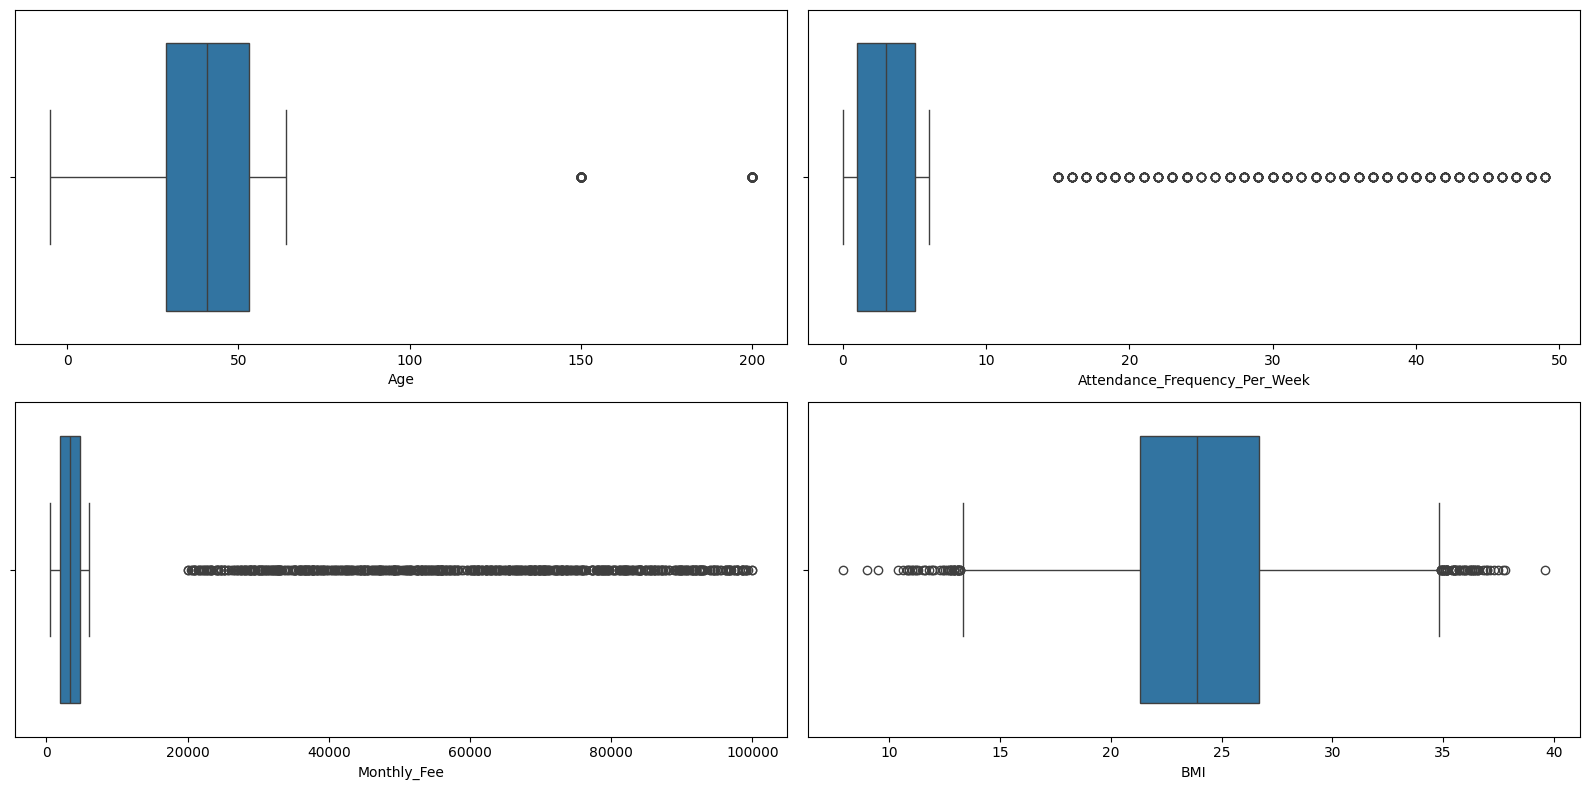

In [14]:
fig, ax = plt.subplots(2,2,figsize=(16,8))
sns.boxplot(x=df['Age'],ax=ax[0,0])
sns.boxplot(x=df['Attendance_Frequency_Per_Week'],ax=ax[0,1])
sns.boxplot(x=df['Monthly_Fee'],ax=ax[1,0])
sns.boxplot(x=df['BMI'],ax=ax[1,1])

plt.tight_layout()


In [15]:
filtered = df[(df['Age']<0) | (df['Age']>100)]
filtered['Age'].unique()

filtered.size


5376

In [16]:
df['Age']=df['Age'].astype('int')


In [17]:
def outlier_impute(columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3-Q1

        upper_limit = Q3 + IQR*1.5
        lower_limit = Q1 - IQR*1.5

        if col == 'Age':
            df.loc[df[col]<=0, col]=np.nan
            df.loc[df[col]>upper_limit,col]=np.nan
        else:
            df.loc[df[col]<lower_limit,col]=lower_limit
            df.loc[df[col]>upper_limit,col]=upper_limit

        

In [18]:
outlier_impute(['Age','Attendance_Frequency_Per_Week','Monthly_Fee','BMI'])

In [19]:
df['Age'].fillna(df['Age'].median(),inplace=True)

In [20]:
df.describe()

,Age,Membership_Duration_Months,Attendance_Frequency_Per_Week,Last_Checkin_Days_Ago,Monthly_Fee,Payment_Delay_Count,Customer_Satisfaction_Score,Workout_Sessions_Completed,Group_Class_Participation,BMI,Distance_From_Gym_km,App_Usage_Hours,Renewal_Count,Churn_Status
count,16213.000000,16213.000000,16213.000000,16213.000000,16213.000000,16213.000000,16213.000000,16213.000000,16213.000000,16213.000000,16213.000000,16213.000000,16213.000000,16213.000000
mean,40.931475,30.061617,3.239684,44.470487,3503.537809,4.510023,5.497132,250.623389,14.522790,23.990464,12.784852,19.989823,3.517918,0.449824
std,13.307901,16.958803,2.417534,25.956391,1950.988537,2.882663,2.870843,142.344625,8.704886,3.984640,7.076587,11.558520,2.289498,0.497491
min,18.000000,1.000000,0.000000,0.000000,500.000000,0.000000,1.000000,1.000000,0.000000,13.200000,0.500000,0.000000,0.000000,0.000000
25%,30.000000,15.000000,1.000000,22.000000,1940.000000,2.000000,3.000000,129.000000,7.000000,21.300000,6.600000,10.100000,2.000000,0.000000
50%,41.000000,30.000000,3.000000,45.000000,3386.000000,5.000000,5.000000,250.000000,15.000000,23.900000,12.800000,20.000000,4.000000,0.000000
75%,52.000000,45.000000,5.000000,67.000000,4803.000000,7.000000,8.000000,373.000000,22.000000,26.700000,18.900000,30.000000,6.000000,1.000000
max,64.000000,59.000000,11.000000,89.000000,9097.500000,9.000000,10.000000,499.000000,29.000000,34.800000,25.000000,40.000000,7.000000,1.000000


In [21]:
df.columns

Index(['Member_ID', 'Name', 'Age', 'Gender', 'Membership_Type',
       'Membership_Duration_Months', 'Attendance_Frequency_Per_Week',
       'Last_Checkin_Days_Ago', 'Monthly_Fee', 'Payment_Delay_Count',
       'Customer_Satisfaction_Score', 'Workout_Sessions_Completed',
       'Personal_Trainer', 'Group_Class_Participation', 'BMI',
       'Distance_From_Gym_km', 'App_Usage_Hours', 'Renewal_Count', 'Goal_Type',
       'UPI_Payment_Usage', 'Churn_Status'],
      dtype='object')

### Lets Do Some EDA

In [22]:
df['Churn_Status'].value_counts(normalize=True)

Churn_Status
0    0.550176
1    0.449824
Name: proportion, dtype: float64

In [23]:
pd.crosstab(df['Goal_Type'],df['Gender'])

Gender,Female,Male,Other,Unknown
Goal_Type,,,,
Athletic Training,1393,1847,56,40
Bodybuilding,1356,1685,64,25
Fitness,1368,1727,60,44
Muscle Gain,1409,1775,53,28
Weight Loss,1418,1762,73,30


In [24]:
pd.crosstab(df['Gender'],df['Membership_Type'])

Membership_Type,Annual,Half-Yearly,Monthly,Premium,Quarterly
Gender,,,,,
Female,1424,1398,1367,1390,1365
Male,1708,1729,1787,1789,1783
Other,52,69,54,67,64
Unknown,38,40,24,32,33


In [25]:
df.groupby(['Gender','Churn_Status']).agg(
    Atten_Freq_Week= ('Attendance_Frequency_Per_Week','count'),
    Atten_Median_Week= ('Attendance_Frequency_Per_Week','median'),
    Work_Sess_com= ('Workout_Sessions_Completed','median'),
    BMI = ('BMI','median')
).reset_index()

,Gender,Churn_Status,Atten_Freq_Week,Atten_Median_Week,Work_Sess_com,BMI
0,Female,0,3852,4.0,254.5,24.1
1,Female,1,3092,2.0,252.0,24.1
2,Male,0,4818,4.0,248.0,23.9
3,Male,1,3978,2.0,247.0,23.7
4,Other,0,157,4.0,240.0,23.6
5,Other,1,149,2.0,221.0,23.7
6,Unknown,0,93,4.0,251.0,24.5
7,Unknown,1,74,3.0,244.5,23.8


<Axes: xlabel='Age', ylabel='Count'>

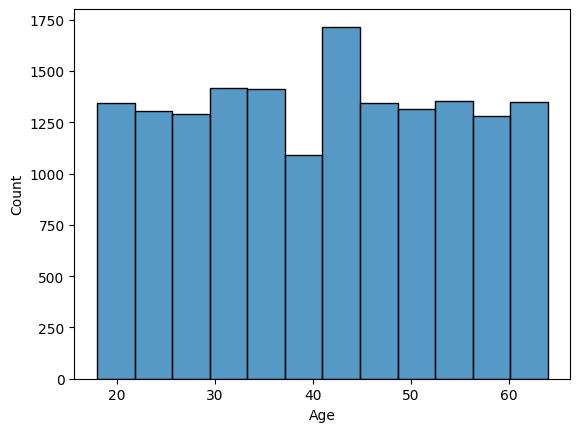

In [26]:
sns.histplot(x=df['Age'],kde=False,binwidth=4)

In [27]:
df['Age_category'] = pd.cut(df['Age'],bins=[0,25,35,45,55,100],labels=['18-25','26-35','36-45','46-55','56-65'])




In [28]:
churned_age = df.groupby('Age_category')[['Churn_Status']].mean()*100
churned_age

C:\Users\maneo\AppData\Local\Temp\ipykernel_84252\2232073266.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churned_age = df.groupby('Age_category')[['Churn_Status']].mean()*100


,Churn_Status
Age_category,
18-25,43.676859
26-35,45.523476
36-45,45.249806
46-55,43.474293
56-65,46.834171


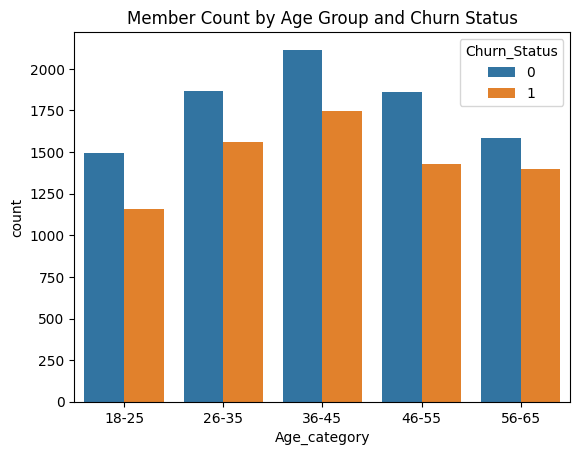

In [29]:
sns.countplot(x=df['Age_category'],hue=df['Churn_Status'])
plt.title('Member Count by Age Group and Churn Status')
plt.show()


In [30]:
churn_gender = df.groupby(['Gender','Churn_Status']).agg(
    Total_count=('Name','count')
)
churn_gender

Total_count
Gender  Churn_Status             
Female  0                    3852
        1                    3092
Male    0                    4818
        1                    3978
Other   0                     157
        1                     149
Unknown 0                      93
        1                      74

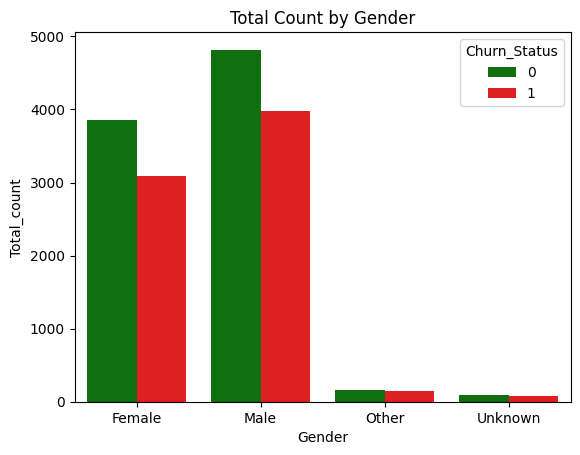

In [31]:
sns.barplot(churn_gender,x='Gender',y='Total_count',hue='Churn_Status',palette={1:'red',0:'green'})
plt.title('Total Count by Gender')
plt.show()

In [32]:
df['early_member'] = np.where(df['Membership_Duration_Months']>12,'old_member','new_member')

In [33]:
member_churn = df.groupby('early_member')[['Churn_Status']].count()
member_churn['churn%'] = round((member_churn['Churn_Status']/len(df))*100,2)
member_churn

,Churn_Status,churn%
early_member,,
new_member,3241,19.99
old_member,12972,80.01


In [34]:
churn_membership = df.groupby(['Membership_Type','Churn_Status']).agg(Total_count = ('Name','count')).reset_index()

churn_membership['churn%'] = (churn_membership['Total_count']/churn_membership.groupby('Membership_Type')['Total_count'].transform('sum')*100)
churn_membership

,Membership_Type,Churn_Status,Total_count,churn%
0,Annual,0,1740,54.003724
1,Annual,1,1482,45.996276
2,Half-Yearly,0,1749,54.048208
3,Half-Yearly,1,1487,45.951792
4,Monthly,0,1798,55.631188
5,Monthly,1,1434,44.368812
6,Premium,0,1835,55.979256
7,Premium,1,1443,44.020744
8,Quarterly,0,1798,55.408320
9,Quarterly,1,1447,44.591680


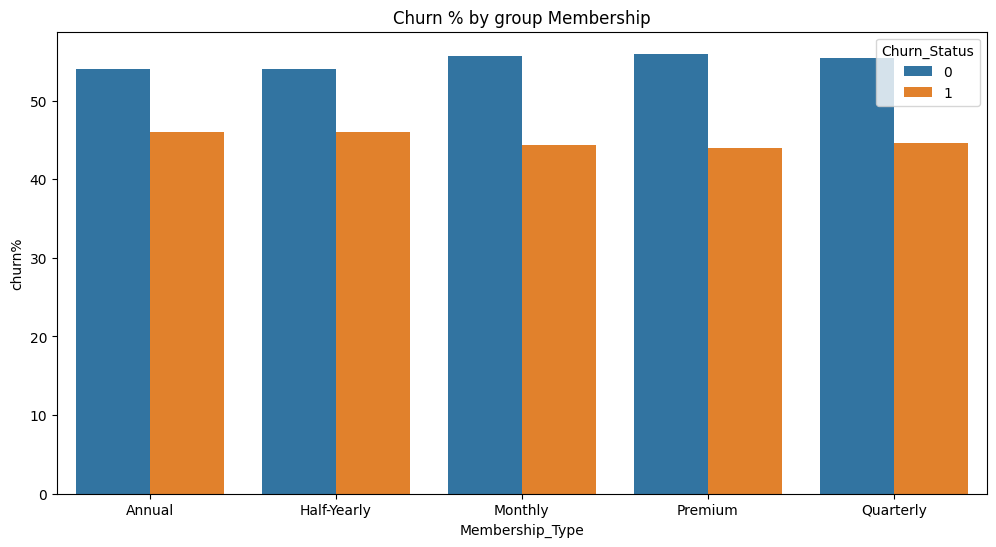

In [35]:
plt.figure(figsize=(12,6))
sns.barplot(x =churn_membership['Membership_Type'],y=churn_membership['churn%'],hue=churn_membership['Churn_Status'])
plt.title('Churn % by group Membership')
plt.show()

<Axes: xlabel='Distance_From_Gym_km', ylabel='Count'>

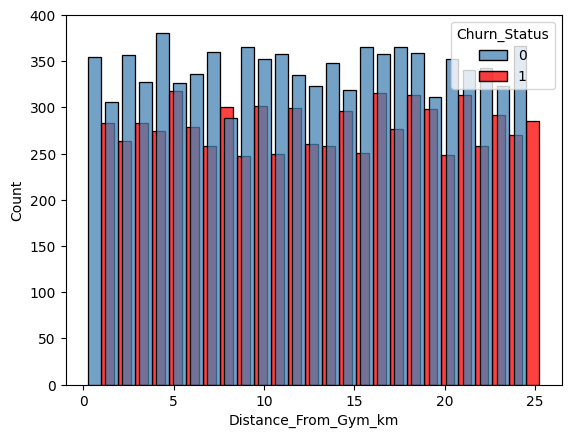

In [36]:
sns.histplot(x=df['Distance_From_Gym_km'],hue=df['Churn_Status'],multiple='dodge',stat='count',shrink=1.5,palette={0:'steelblue',1:'red'})

In [37]:
numeric_df = df.select_dtypes(include=[np.number])

corr_mat = numeric_df.corr()['Churn_Status'].drop('Churn_Status').sort_values(key=abs,ascending=False)
corr_mat1 =numeric_df.corr(method='pearson').round(3) 
corr_mat.round(3)

Last_Checkin_Days_Ago            0.247
Attendance_Frequency_Per_Week   -0.192
Customer_Satisfaction_Score     -0.176
Payment_Delay_Count              0.129
Age                              0.009
App_Usage_Hours                  0.009
Renewal_Count                    0.009
Membership_Duration_Months      -0.007
Monthly_Fee                     -0.006
BMI                             -0.002
Workout_Sessions_Completed       0.002
Group_Class_Participation        0.001
Distance_From_Gym_km             0.000
Name: Churn_Status, dtype: float64

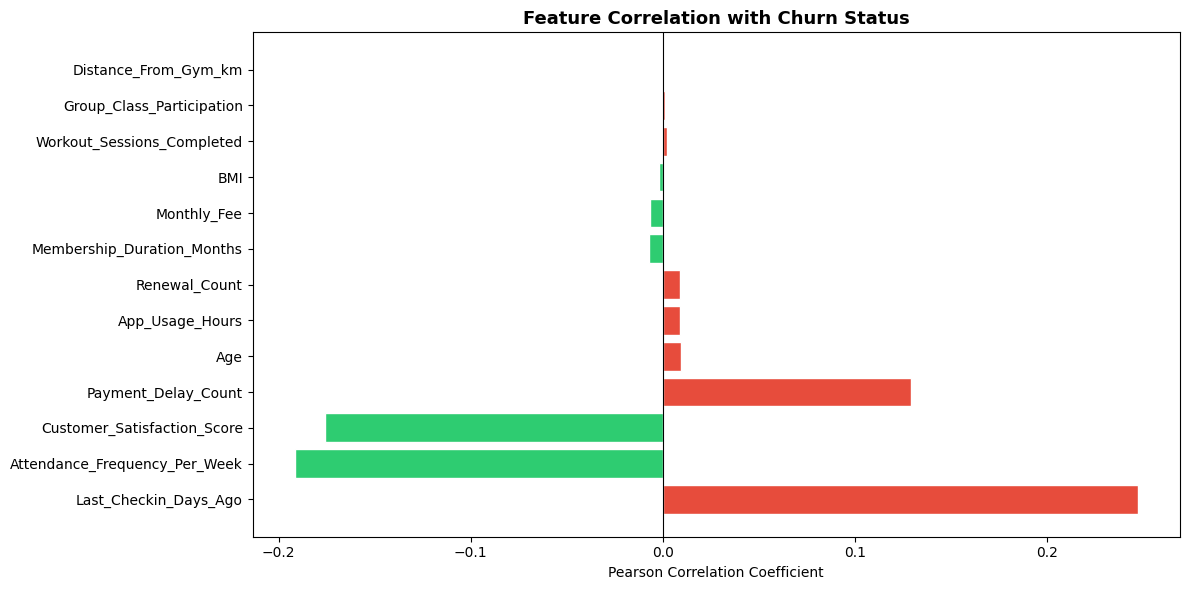

In [38]:
fig, ax = plt.subplots(figsize = (12,6))
colors = ['#e74c3c' if v >0 else '#2ecc71' for v in corr_mat.values]
ax.barh(corr_mat.index,corr_mat.values,color=colors,edgecolor ='white')
ax.axvline(0,color ='black',linewidth=0.8)
ax.set_title('Feature Correlation with Churn Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

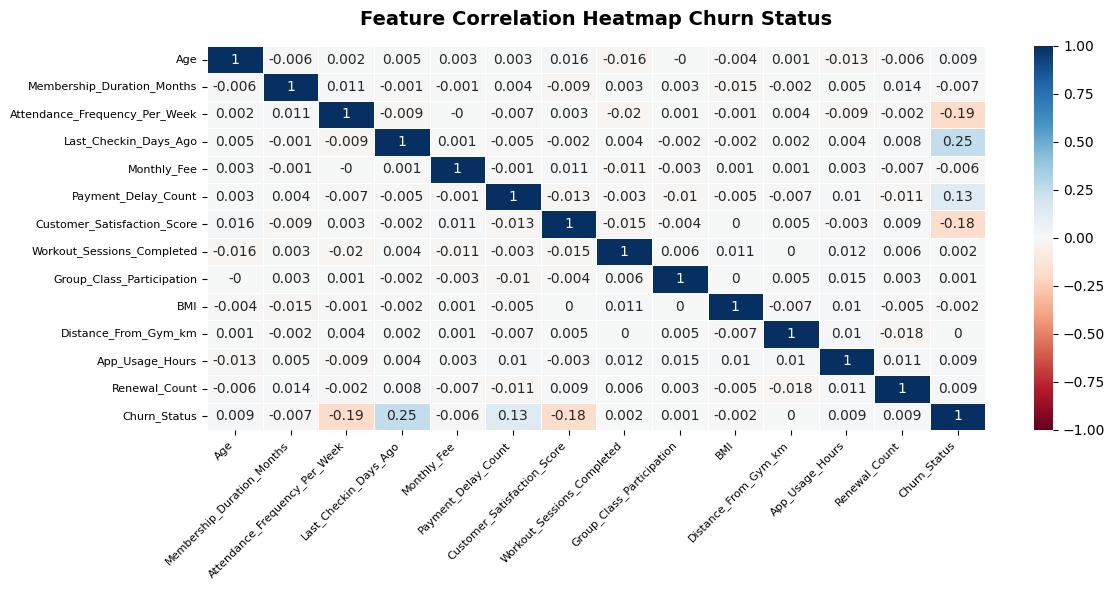

In [39]:
plt.figure(figsize=(12,6))
sns.heatmap(corr_mat1,annot=True,cmap='RdBu',vmin=-1,vmax=1,linewidths=0.5)
plt.title('Feature Correlation Heatmap Churn Status', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [40]:
numeric_df1 = numeric_df.drop(columns=['Churn_Status']).reset_index(drop=True)
vif_df = pd.DataFrame({
    'Features': numeric_df1.columns,
    "VIF":[variance_inflation_factor(numeric_df1.values,i) for i in range(numeric_df1.shape[1])]
})
vif_df = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)

def vif_severity(v):
    if v > 10: return '🔴 Severe'
    if v > 5:  return '🟡 Moderate'
    return '🟢 Acceptable'


vif_df['Severity'] = vif_df['VIF'].apply(vif_severity)
print(vif_df.to_string(index=False))

                     Features       VIF     Severity
                          BMI 19.948364     🔴 Severe
                          Age  9.181100   🟡 Moderate
  Customer_Satisfaction_Score  4.458430 🟢 Acceptable
         Distance_From_Gym_km  4.083768 🟢 Acceptable
                  Monthly_Fee  4.054659 🟢 Acceptable
   Membership_Duration_Months  3.966148 🟢 Acceptable
   Workout_Sessions_Completed  3.941871 🟢 Acceptable
              App_Usage_Hours  3.865419 🟢 Acceptable
        Last_Checkin_Days_Ago  3.791015 🟢 Acceptable
    Group_Class_Participation  3.655530 🟢 Acceptable
          Payment_Delay_Count  3.330276 🟢 Acceptable
                Renewal_Count  3.260790 🟢 Acceptable
Attendance_Frequency_Per_Week  2.730037 🟢 Acceptable


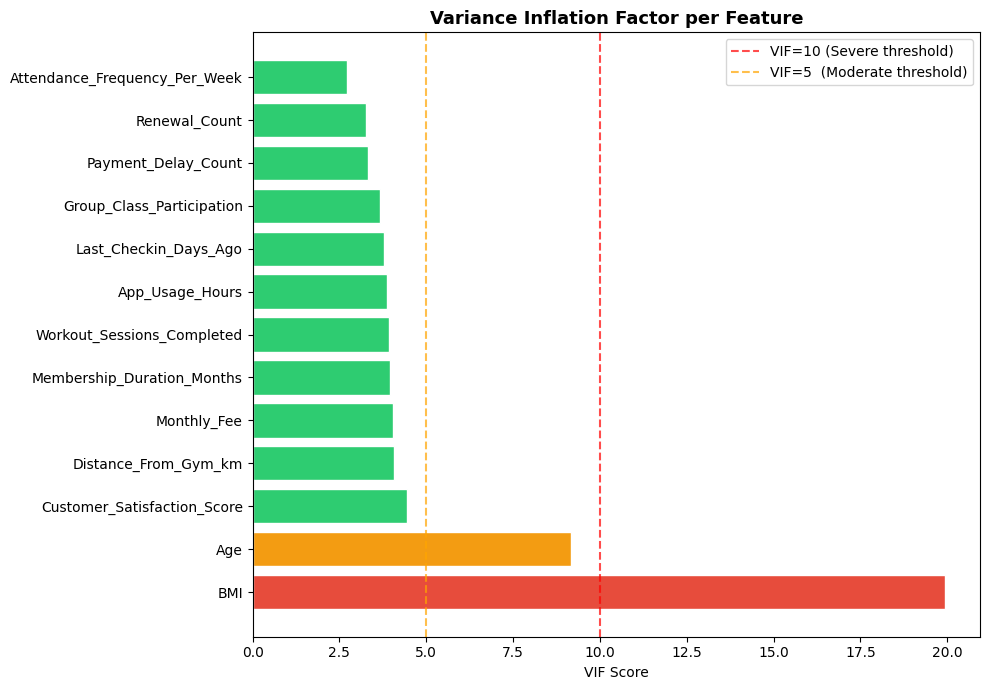

In [41]:
fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#2ecc71'
              for v in vif_df['VIF']]
ax.barh(vif_df['Features'], vif_df['VIF'], color=bar_colors, edgecolor='white')
ax.axvline(10, color='red',    linestyle='--', alpha=0.7, label='VIF=10 (Severe threshold)')
ax.axvline(5,  color='orange', linestyle='--', alpha=0.7, label='VIF=5  (Moderate threshold)')
ax.set_title('Variance Inflation Factor per Feature', fontsize=13, fontweight='bold')
ax.set_xlabel('VIF Score')
ax.legend()
plt.tight_layout()
plt.show()

In [42]:
y = df['Churn_Status']
X = df.drop(columns=['Member_ID', 'Name','Churn_Status','early_member','Age_category'])

X = pd.get_dummies(X,drop_first=True,dtype='uint8')

In [43]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Lasso Regression with Cross-Validated Alpha

In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# LASSO REGRESSION (L1 Regularization)
#
# Lasso adds penalty: λ * Σ|βᵢ|
#
# Effect: Pushes coefficients toward EXACTLY ZERO.
#         This means Lasso performs automatic FEATURE SELECTION.
#         Features with zero coefficients are considered irrelevant.
#
# LassoCV: Automatically finds the optimal regularization strength (alpha/λ)
#          via k-fold cross-validation on the training set.
# ─────────────────────────────────────────────────────────────────────────────

In [45]:
alphas_lasso = [0.001,0.005,0.02,0.01,0.03]
lasso_cv = LassoCV(alphas=alphas_lasso,
                   cv=5,
                   max_iter=5000,
                   random_state=0,
                   n_jobs=-1)

model = lasso_cv.fit(X_train_scaled,y_train)


In [46]:
best_alpha = model.alpha_
print(best_alpha)

lasso_model = Lasso(alpha=best_alpha,max_iter=5000,random_state=0)
lasso_model.fit(X_train_scaled,y_train)

0.005


Lasso(alpha=0.005, max_iter=5000, random_state=0)

In [47]:
y_pred_lasso_train = lasso_model.predict(X_train_scaled)
y_pred_lasso_test = lasso_model.predict(X_test_scaled)

print("\nLasso Model Performance:")
print(f"{'Metric':<8} {'Train':>10} {'Test':>10}")
print("-" * 30)

metrics_lasso = {
    'MAE'   : {'Train': mean_absolute_error(y_train, y_pred_lasso_train),
               'Test' : mean_absolute_error(y_test,  y_pred_lasso_test)},
    'RMSE'  : {'Train': np.sqrt(mean_squared_error(y_train, y_pred_lasso_train)),
               'Test' : np.sqrt(mean_squared_error(y_test,  y_pred_lasso_test))},
    'R²'    : {'Train': r2_score(y_train, y_pred_lasso_train),
               'Test' : r2_score(y_test,  y_pred_lasso_test)},
}
for m, vals in metrics_lasso.items():
    print(f"{m:<8} {vals['Train']:>10.4f} {vals['Test']:>10.4f}")






Lasso Model Performance:
Metric        Train       Test
------------------------------
MAE          0.4273     0.4293
RMSE         0.4599     0.4619
R²           0.1462     0.1347


In [48]:
lasso_coefs = pd.DataFrame({"Feature":X.columns,
                            "Value":lasso_model.coef_})
zeroed_features = lasso_coefs[lasso_coefs == 0].index.tolist()
not_zeroed_features = lasso_coefs[lasso_coefs != 0].index.tolist()

print(lasso_coefs)
print(zeroed_features)
print(not_zeroed_features)

                          Feature     Value
0                             Age  0.000388
1      Membership_Duration_Months -0.000000
2   Attendance_Frequency_Per_Week -0.089653
3           Last_Checkin_Days_Ago  0.120699
4                     Monthly_Fee -0.000147
5             Payment_Delay_Count  0.056491
6     Customer_Satisfaction_Score -0.080525
7      Workout_Sessions_Completed  0.000000
8       Group_Class_Participation -0.000000
9                             BMI  0.000000
10           Distance_From_Gym_km  0.000000
11                App_Usage_Hours  0.000000
12                  Renewal_Count  0.001664
13                    Gender_Male  0.000000
14                   Gender_Other  0.000000
15                 Gender_Unknown -0.000000
16    Membership_Type_Half-Yearly  0.000000
17        Membership_Type_Monthly -0.000365
18        Membership_Type_Premium -0.000000
19      Membership_Type_Quarterly -0.000000
20           Personal_Trainer_Yes  0.000000
21         Goal_Type_Bodybuildin

## Ridge Regression with Cross-Validated Alpha

In [49]:
alphas_ridge = [0.001,0.005,0.01,0.05,0.1,1,10,100]

ridge_cv = RidgeCV(
    alphas=alphas_ridge,cv=5,scoring='neg_mean_squared_error'
)

model_rid = ridge_cv.fit(X_train_scaled,y_train)
best_ridge = model.alpha_
print("Best Alpha ridge:", best_ridge)

Best Alpha ridge: 0.005


In [50]:
ridge_model = Ridge(alpha=best_ridge)
ridge_model.fit(X_train_scaled,y_train)

y_pred_ridge_train = ridge_model.predict(X_train_scaled)
y_pred_ridge_test = ridge_model.predict(X_test_scaled)


metrics_ridge = {
    'MAE'   : {'Train': mean_absolute_error(y_train, y_pred_ridge_train),
               'Test' : mean_absolute_error(y_test,  y_pred_ridge_test)},
    'RMSE'  : {'Train': np.sqrt(mean_squared_error(y_train, y_pred_ridge_train)),
               'Test' : np.sqrt(mean_squared_error(y_test,  y_pred_ridge_test))},
    'R²'    : {'Train': r2_score(y_train, y_pred_ridge_train),
               'Test' : r2_score(y_test,  y_pred_ridge_test)},
}
print("Ridge Model Performance:")
print(f"{'Metric':<8} {'Train':>10} {'Test':>10}")



for m, vals in metrics_ridge.items():
    print(f"{m:<8} {vals['Train']:>10.4f} {vals['Test']:>10.4f}")


Ridge Model Performance:
Metric        Train       Test
MAE          0.4236     0.4262
RMSE         0.4596     0.4621
R²           0.1475     0.1343


In [51]:
comparison_data = {
    'Model': ['Lasso (L1)', 'Ridge (L2)'],
    'Best Alpha'  : [best_alpha, best_ridge],
    'Train MAE'   : [metrics_lasso['MAE']['Train'],  metrics_ridge['MAE']['Train']],
    'Test MAE'    : [metrics_lasso['MAE']['Test'],   metrics_ridge['MAE']['Test']],
    'Train RMSE'  : [metrics_lasso['RMSE']['Train'], metrics_ridge['RMSE']['Train']],
    'Test RMSE'   : [metrics_lasso['RMSE']['Test'],  metrics_ridge['RMSE']['Test']],
    'Train R²'    : [metrics_lasso['R²']['Train'],   metrics_ridge['R²']['Train']],
    'Test R²'     : [metrics_lasso['R²']['Test'],    metrics_ridge['R²']['Test']],
    'Overfitting Gap': [
        metrics_lasso['R²']['Train'] - metrics_lasso['R²']['Test'],
        metrics_ridge['R²']['Train'] - metrics_ridge['R²']['Test']
    ]
}

comp_df = pd.DataFrame(comparison_data).set_index('Model')
comp_df

,Best Alpha,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²,Overfitting Gap
Model,,,,,,,,
Lasso (L1),0.005,0.427323,0.429318,0.459921,0.46195,0.146186,0.134679,0.011507
Ridge (L2),0.005,0.423555,0.426178,0.459559,0.46206,0.147530,0.134268,0.013262


In [52]:
coef_df = pd.DataFrame({
    'Feature'      : X.columns,
    'Lasso Coef'   : lasso_model.coef_,
    'Ridge Coef'   : ridge_model.coef_,
    'Lasso Zeroed?': lasso_model.coef_ == 0
}).sort_values('Ridge Coef', key=abs, ascending=False)

print("Coefficient Comparison Table (sorted by |Ridge Coef|):")
display(coef_df.round(4))

Coefficient Comparison Table (sorted by |Ridge Coef|):


,Feature,Lasso Coef,Ridge Coef,Lasso Zeroed?
3,Last_Checkin_Days_Ago,0.1207,0.1257,False
2,Attendance_Frequency_Per_Week,-0.0897,-0.0944,False
6,Customer_Satisfaction_Score,-0.0805,-0.0856,False
5,Payment_Delay_Count,0.0565,0.0614,False
12,Renewal_Count,0.0017,0.0066,False
17,Membership_Type_Monthly,-0.0004,-0.0064,False
22,Goal_Type_Fitness,0.0000,0.0064,True
0,Age,0.0004,0.0055,False
14,Gender_Other,0.0000,0.0053,True
4,Monthly_Fee,-0.0001,-0.0051,False


In [53]:
log_l1 = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=800,
    random_state=42
)

log_l1.fit(X_train_scaled, y_train)

# Probability of churn
churn_prob = log_l1.predict_proba(X_test_scaled)[:,1]

# Convert to %
churn_percentage_l1 = churn_prob * 100

results_l1 = pd.DataFrame({
    'Actual_Churn': y_test,
    'Predicted_Churn_Percentage': churn_percentage_l1
})

results_l1.head()

,Actual_Churn,Predicted_Churn_Percentage
1086,0,20.371646
13648,0,16.008176
2301,0,38.447308
7039,1,64.875292
4885,0,62.548609


In [54]:
log_l2 = LogisticRegression(
    penalty='l2',
    solver='liblinear',
    random_state=42
)

log_l2.fit(X_train_scaled, y_train)

churn_prob_l2 = log_l2.predict_proba(X_test_scaled)[:,1]*100

results_l2 = pd.DataFrame({
    'Actual_Churn': y_test,
    'Predicted_Churn_Percentage': churn_prob_l2
})

results_l2.head()

,Actual_Churn,Predicted_Churn_Percentage
1086,0,20.299343
13648,0,15.910902
2301,0,38.374286
7039,1,64.891650
4885,0,62.597518


In [56]:
results_l1['Risk_Level'] = pd.cut(
    results_l1['Predicted_Churn_Percentage'],
    bins=[0,30,70,100],
    labels=['Low Risk','Medium Risk','High Risk']
)

results_l1['Risk_Level'].value_counts()

Risk_Level
Medium Risk    2563
Low Risk       1025
High Risk       466
Name: count, dtype: int64

In [58]:
results_l2['Risk_Level'] = pd.cut(
    results_l2['Predicted_Churn_Percentage'],
    bins=[0,30,70,100],
    labels=['Low Risk','Medium Risk','High Risk']
)

results_l2['Risk_Level'].value_counts()

Risk_Level
Medium Risk    2563
Low Risk       1026
High Risk       465
Name: count, dtype: int64

C:\Users\maneo\AppData\Local\Temp\ipykernel_84252\4271341999.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=results_l2['Risk_Level'],palette={'Low Risk':'green',


<Axes: xlabel='Risk_Level', ylabel='count'>

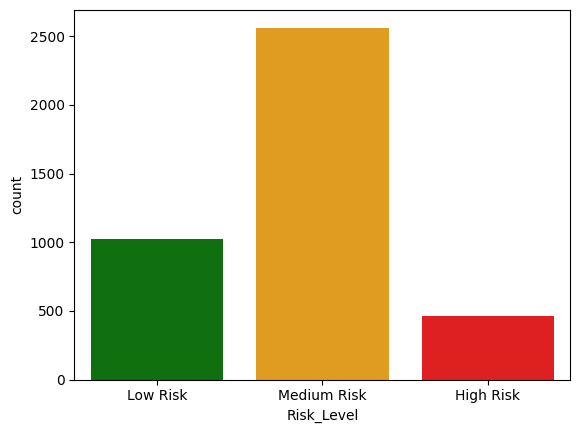

In [59]:
sns.countplot(x=results_l2['Risk_Level'],palette={'Low Risk':'green',
                                                  'Medium Risk':'orange',
                                                  'High Risk':'red'})